![image info](https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/images/banner_1.png)

# Taller: Construcción e implementación de árboles de decisión y métodos de ensamblaje

En este taller podrá poner en práctica los sus conocimientos sobre construcción e implementación de árboles de decisión y métodos de ensamblajes. El taller está constituido por 9 puntos, 5 relacionados con árboles de decisión (parte A) y 4 con métodos de ensamblaje (parte B).

## Parte A - Árboles de decisión

En esta parte del taller se usará el conjunto de datos de Capital Bikeshare de Kaggle, donde cada observación representa el alquiler de bicicletas durante una hora y día determinado. Para más detalles puede visitar los siguientes enlaces: [datos](https://archive.ics.uci.edu/ml/machine-learning-databases/00275/Bike-Sharing-Dataset.zip), [dicccionario de datos](https://archive.ics.uci.edu/ml/datasets/Bike+Sharing+Dataset#).

### Datos prestamo de bicicletas

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [50]:
# Importación de librerías
%matplotlib inline
import pandas as pd
import numpy as np
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeRegressor,DecisionTreeClassifier, export_graphviz
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from sklearn.metrics import accuracy_score, f1_score

In [3]:
# Lectura de la información de archivo .csv
bikes = pd.read_csv('https://raw.githubusercontent.com/davidzarruk/MIAD_ML_NLP_2023/main/datasets/bikeshare.csv', index_col='datetime', parse_dates=True)

# Renombrar variable "count" a "total"
bikes.rename(columns={'count':'total'}, inplace=True)

# Crear la hora como una variable 
bikes['hour'] = bikes.index.hour

# Visualización de los datos
bikes.head()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,total,hour
datetime,,,,,,,,,,,,
2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,0
2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,1
2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,2
2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,3
2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,4


### Punto 1 - Análisis descriptivo

Ejecute las celdas 1.1 y 1.2. A partir de los resultados realice un análisis descriptivo sobre las variables "season" y "hour", escriba sus inferencias sobre los datos. Para complementar su análisis puede usar métricas como máximo, mínimo, percentiles entre otros.

In [4]:
# Celda 1.1
bikes.groupby('season').total.mean()

season
1    116.343261
2    215.251372
3    234.417124
4    198.988296
Name: total, dtype: float64

In [5]:
bikes.groupby('season').temp.mean()

season
1    12.530491
2    22.823483
3    28.789111
4    16.649239
Name: temp, dtype: float64

In [6]:
# Celda 1.2
bikes.groupby('hour').total.mean()

hour
0      55.138462
1      33.859031
2      22.899554
3      11.757506
4       6.407240
5      19.767699
6      76.259341
7     213.116484
8     362.769231
9     221.780220
10    175.092308
11    210.674725
12    256.508772
13    257.787281
14    243.442982
15    254.298246
16    316.372807
17    468.765351
18    430.859649
19    315.278509
20    228.517544
21    173.370614
22    133.576754
23     89.508772
Name: total, dtype: float64

In [7]:
max_hour = bikes.groupby('hour').total.mean().idxmax()
max_value = bikes.groupby('hour').total.mean().max()

min_hour = bikes.groupby('hour').total.mean().idxmin()
min_value = bikes.groupby('hour').total.mean().min()
print(f" máxima: {max_hour} ({max_value:.2f})")
print(f" mínima: {min_hour} ({min_value:.2f})")

 máxima: 17 (468.77)
 mínima: 4 (6.41)


#### Punto 1- analisis

Sobre el análisis descriptivo, teniendo en cuenta las variables analizadas, se puede determinar que la temporada con mayor renta de ciclas corresponde a la temporada 3, seguida de la temporada 2. Por su parte, la temporada 1 presenta el menor número de rentas, con aproximadamente la mitad de las registradas en la temporada 3. Estos resultados pueden explicarse a partir de la temperatura y las condiciones climáticas características de cada temporada. En particular, la temporada 1 presenta temperaturas más bajas, lo que genera condiciones menos favorables para el uso de este medio de transporte, mientras que la temporada 3 registra la temperatura promedio más alta. Esto evidencia una relación clara entre las condiciones climáticas y la renta de ciclas.

Por otro lado, con respecto a la variable hora, se observa que la mayor demanda en la renta de ciclas se presenta a las 17:00, mientras que el valor mínimo se registra a las 4:00. Este comportamiento resulta coherente con la dinámica cotidiana, ya que las 5 pm corresponde a un horario en el que muchas personas finalizan sus jornadas laborales o académicas, lo que sugiere un uso predominante de la bicicleta como medio de transporte sostenible, más que con fines recreativos. De manera similar, las 4 am corresponde a un horario con baja actividad de desplazamiento, lo que explica que el promedio de renta en ese momento sea cercano a 6 ciclas.

Adicionalmente, resulta pertinente analizar rangos horarios, más que únicamente horas específicas. En este sentido, se observa que entre las 7:00 am y las 9:00 pm el promedio de rentas supera las 150 ciclas, con especial concentración entre las 7:00 am y 9:00 am en el horario matutino, y entre las 4:00 pm y 7:00 pm en el horario de la tarde. Estas franjas corresponden a los principales horarios de desplazamiento entre los lugares de residencia y trabajo o estudio, lo que explica la mayor concentración de la demanda en estos periodos.

Con respecto a lo anterior, se puede ver que las varaibles de horas y temporada estan estrechamente relacionadas con la variable de respuesta (rentas), dependiendo del valor de estas se influyencia drasticamente el comportamiento de las rentas. Por lo que, para la elaboración de un modelo serán muy importantes.

### Punto 2 - Análisis de gráficos

Primero ejecute la celda 2.1 y asegúrese de comprender el código y el resultado. Luego, en cada una de celdas 2.2 y 2.3 escriba un código que genere una gráfica del número de bicicletas rentadas promedio para cada valor de la variable "hour" (hora) cuando la variable "season" es igual a 1 (invierno) e igual a 3 (verano), respectivamente. Analice y escriba sus hallazgos.

<Axes: title={'center': 'Rentas promedio por hora'}, xlabel='Hora del día', ylabel='Rentas promedio'>

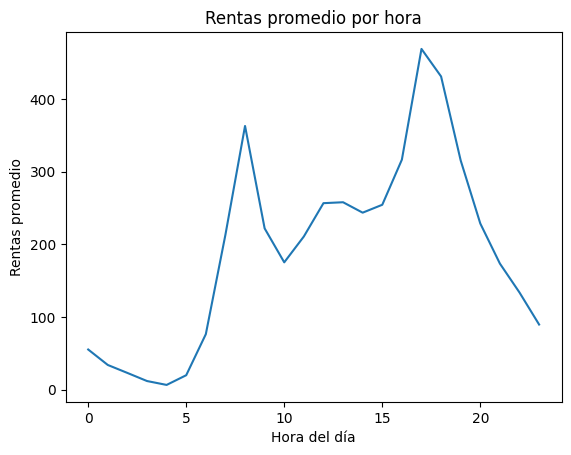

In [8]:
# Celda 2.1 - rentas promedio para cada valor de la variable "hour"
bikes.groupby('hour').total.mean().plot(title='Rentas promedio por hora', xlabel='Hora del día', ylabel='Rentas promedio')


<Axes: title={'center': 'Rentas promedio por hora (invierno)'}, xlabel='Hora del día', ylabel='Rentas promedio'>

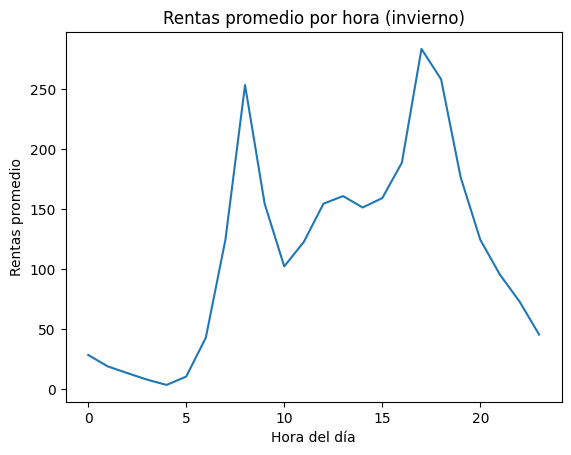

In [9]:
# Celda 2.2 - "season"=1 escriba su código y hallazgos 
bikes[bikes["season"] == 1].groupby('hour').total.mean().plot(title='Rentas promedio por hora (invierno)', xlabel='Hora del día', ylabel='Rentas promedio')

<Axes: title={'center': 'Rentas promedio por hora (verano)'}, xlabel='Hora del día', ylabel='Rentas promedio'>

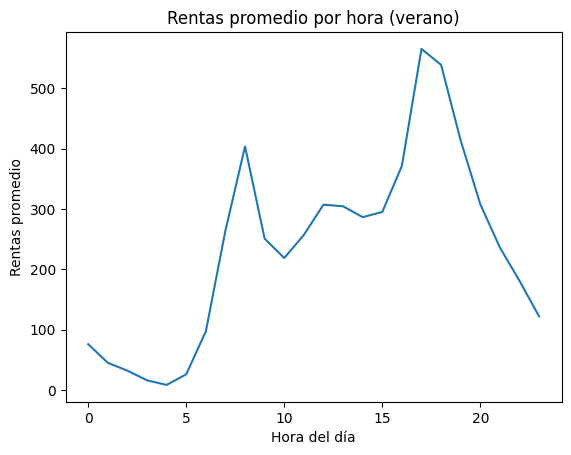

In [10]:
# Celda 2.3 - "season"=3 escriba su código y hallazgos 
bikes[bikes["season"] == 3].groupby('hour').total.mean().plot(title='Rentas promedio por hora (verano)', xlabel='Hora del día', ylabel='Rentas promedio')

In [11]:
bikes[bikes["season"] == 3].groupby('hour').total.mean()

hour
0      75.675439
1      44.831858
2      31.707965
3      15.778761
4       8.087719
5      25.728070
6      96.780702
7     264.035088
8     403.508772
9     250.710526
10    218.535088
11    256.877193
12    307.017544
13    304.421053
14    286.350877
15    294.956140
16    371.324561
17    565.385965
18    539.070175
19    413.500000
20    307.842105
21    236.017544
22    180.789474
23    121.719298
Name: total, dtype: float64

#### Punto 2- Analisis

Inicialmente, se puede observar que ambas temporadas presentan un comportamiento similar en el patrón horario de uso. Es decir, dejando a un lado la magnitud de las rentas, independientemente de la temporada analizada, la variable hora mantiene un comportamiento consistente y presenta los mismos picos de uso.

Teniendo esto en cuenta, se puede reiterar lo observado en el análisis descriptivo previo, donde las 17:00 corresponden a la hora con mayor renta de bicicletas, mientras que las 4:00 registran la menor demanda, sin importar la temporada. Asimismo, se observa que en verano la magnitud de la escala es aproximadamente el doble, lo que indica que la renta de bicicletas aumenta considerablemente dependiendo de la temporada analizada. Esto se evidencia en que, a las 17:00, en verano se alcanza aproximadamente un promedio de 565 rentas, mientras que en invierno el promedio es cercano a 283 rentas.

Adicionalmente, se puede observar que en el rango entre 0:00 y 5:00 existe una demanda muy baja en ambas temporadas. Esto puede explicarse porque corresponde a horarios en los que la mayoría de las personas no se encuentran realizando desplazamientos, lo que reduce significativamente el uso del sistema de bicicletas.

Finalmente, en conclusión, se puede afirmar que el patrón de uso horario es similar a lo largo del año, pero la temporada, asociada principalmente con la temperatura exterior, influye de manera importante en la cantidad total de rentas. Esto genera que la diferencia entre invierno y verano sea significativamente alta, evidenciando el impacto de las condiciones climáticas sobre la demanda del servicio.

### Punto 3 - Regresión lineal
En la celda 3 ajuste un modelo de regresión lineal a un conjunto de train de datos, utilizando "total" como variable de respuesta y "season" y "hour" como las únicas variables predictoras, teniendo en cuenta que la variable "season" es categórica. Luego, imprima los coeficientes e interprételos. ¿Cuáles son las limitaciones de la regresión lineal en este caso?

In [12]:
# Celda 3
from sklearn.model_selection import train_test_split
xtotal = bikes[["season", "hour"]]
xtotal = pd.get_dummies(bikes[["season", "hour"]], columns=["season"], drop_first=True)
ytotal = bikes["total"]
XTrain, XTest, yTrain, yTest = train_test_split(xtotal, ytotal, test_size=0.33, random_state=0)

m3=LinearRegression()
m3.fit(XTrain, yTrain)
print( f'El R^2 es: {m3.score(XTest, yTest)}')
rmse_m3=np.sqrt(np.mean((m3.predict(XTest) - yTest)**2))
print( f'El RMSE es: {rmse_m3}')

pd.DataFrame({'feature': XTrain.columns, 'coefficient': m3.coef_})



El R^2 es: 0.21517712032533343
El RMSE es: 160.13875579927014


,feature,coefficient
0,hour,10.628739
1,season_2,100.907768
2,season_3,119.018664
3,season_4,87.247390


#### Punto 3- Analisis

Para tratar la variable season, debido a su naturaleza categórica, se utilizó one-hot encoding, por lo que se excluyó la categoría season_1 con el fin de evitar problemas de multicolinealidad en el modelo. Las demás categorías quedaron representadas como variables indicadoras (season_2, season_3 y season_4).

El modelo arrojó un valor de R2 de 0.215, lo cual indica que su capacidad explicativa es limitada, ya que solo logra explicar aproximadamente el 21.5% de la variabilidad en la renta de bicicletas. Esto sugiere que el modelo no representa completamente el comportamiento de la variable respuesta y no seria adecuado de usar si se quiere implementar en un negocio real. y el RMSE es de 160, lo que equivale a que el modelo en promedio se equivoca en 160 rentas por predicción.

En cuanto a los coeficientes, se puede concluir que al aumentar la variable de hora en una unidad, se espera que en promedio la renta de bicicletas aumente en aproximadamente 10.62 unidades, manteniendo constante la temporada. Aunque es cierto que durante las horas de la tarde la renta de bicicletas es mayor, este aumento no es uniforme a lo largo del día, debido a que la variable hour presenta un comportamiento cíclico, lo cual no es capturado adecuadamente por un modelo lineal.

Por otro lado, la interpretación de las variables dummy es diferente, ya que estas se analizan en relación con la categoría excluida (season_1). En este sentido, se observa que en la temporada 2 se rentan en promedio aproximadamente 101 bicicletas más que en la temporada 1, manteniendo constante la hora del día. En la temporada 3 se rentan aproximadamente 119 bicicletas más, mientras que en la temporada 4 se rentan aproximadamente 87 bicicletas más que en la temporada 1. Estos resultados son consistentes con lo observado previamente en el análisis exploratorio de datos (EDA), donde se identificó que el orden de mayor a menor número de rentas por temporada corresponde a: temporada 3, seguida de la temporada 2, luego la temporada 4, y finalmente la temporada 1.

En cuanto a las limitaciones del modelo, se pueden identificar principalmente cuatro aspectos relevantes
* La variable hour, aunque es continua, en realidad es discreta y cíclica, ya que siempre toma valores enteros dentro del rango de 0 a 23. En un modelo de regresión lineal, esta característica cíclica no se captura adecuadamente, debido a que el modelo asume relaciones lineales entre las variables. Por esta razón, el patrón real de comportamiento de la variable no puede representarse correctamente, lo que afecta el desempeño del modelo.
* La variable season, aunque puede transformarse mediante one-hot encoding para tratar su naturaleza categórica, sigue presentando limitaciones dentro de un modelo de regresión lineal. Esto ocurre porque este tipo de modelo no permite capturar relaciones complejas entre variables categóricas y continuas, como la interacción entre la temporada y la hora del día. Por esta razón, otros algoritmos podrían representar mejor este tipo de relaciones.
* El modelo utiliza únicamente dos variables predictoras, a pesar de que el conjunto de datos incluye otras variables relevantes como temperatura, humedad y velocidad del viento, las cuales influyen significativamente en la renta de bicicletas. Aunque en el análisis exploratorio se evidenció que season y hour tienen impacto sobre la variable respuesta, utilizar solo estas dos variables limita la capacidad explicativa del modelo.
* A partir de las gráficas de renta promedio agrupada por hora, se observa que el comportamiento de la variable respuesta no es lineal, sino que presenta un patrón más complejo con picos en horarios específicos del día. Dado que esta es una de las únicas dos variables incluidas en el modelo, la regresión lineal no logra capturar adecuadamente este comportamiento. Esto se refleja en el valor del r2, el cual evidencia que el modelo no presenta un alto desempeño predictivo.

### Punto 4 - Árbol de decisión manual
En la celda 4 cree un árbol de decisiones para pronosticar la variable "total" iterando **manualmente** sobre las variables "hour" y  "season". El árbol debe tener al menos 6 nodos finales.

In [13]:
def gini(y):
    if y.shape[0] == 0:
        return 0
    else:
        return 1 - (y.mean()**2 + (1 - y.mean())**2)

In [14]:
def gini_impurity(X_col, y, split):
    
    filter_l = X_col < split
    y_l = y.loc[filter_l]
    y_r = y.loc[~filter_l]
    
    n_l = y_l.shape[0]
    n_r = y_r.shape[0]
    
    gini_y = gini(y)
    gini_l = gini(y_l)
    gini_r = gini(y_r)
    
    gini_impurity_ = gini_y - (n_l / (n_l + n_r) * gini_l + n_r / (n_l + n_r) * gini_r)
    
    return gini_impurity_

In [15]:
def best_split(X, y, num_pct=10):
    
    features = range(X.shape[1])
    
    best_split = [0, 0, 0]  # j, split, gain
    
    # Para todas las varibles 
    for j in features:
        
        splits = np.percentile(X.iloc[:, j], np.arange(0, 100, 100.0 / (num_pct+1)).tolist())
        splits = np.unique(splits)[1:]
        
        # Para cada partición
        for split in splits:
            gain = gini_impurity(X.iloc[:, j], y, split)
                        
            if gain > best_split[2]:
                best_split = [j, split, gain]
    
    return best_split

In [16]:
def mse(y):
    if len(y) == 0:
        return 0
    return np.mean((y - y.mean())**2)

def best_split(X, y, num_pct=10):
    
    features = range(X.shape[1])
    best_split = [0, 0, -1]  # j, split, gain
    
    mse_parent = mse(y)
    
    # Para todas las variables
    for j in features:
        
        splits = np.percentile(X.iloc[:, j],np.arange(0, 100, 100.0 / (num_pct + 1)).tolist())
        splits = np.unique(splits)[1:]
        
        # Para cada partición
        for split in splits:
            left = X.iloc[:, j] < split
            right = ~left
            
            if left.sum() == 0 or right.sum() == 0:
                continue
            
            y_left = y[left]
            y_right = y[right]
            
            mse_children = (len(y_left) / len(y)) * mse(y_left) + (len(y_right) / len(y)) * mse(y_right)
            gain = mse_parent - mse_children
                        
            if gain > best_split[2]:
                best_split = [j, split, gain]
    
    return best_split

In [17]:
# Celda 4

def tree_grow(X, y, level=0, min_gain=0.001, max_depth=None, num_pct=10):
    
    # Si solo es una observación
    if X.shape[0] == 1:
        tree = dict(y_pred=y.iloc[:1].values[0], y_prob=0.5, level=level, split=-1, n_samples=1, gain=0)
        return tree
    
    # Calcular la mejor división
    j, split, gain = best_split(X, y, num_pct)
    
    # Guardar el árbol y estimar la predicción
    y_pred = y.mean()
    
    tree = dict(y_pred=y_pred, level=level, split=-1, n_samples=X.shape[0], gain=gain)
    # Revisar el criterio de parada 
    if gain < min_gain:
        return tree
    if max_depth is not None:
        if level >= max_depth:
            return tree   
    
    # Continuar creando la partición
    filter_l = X.iloc[:, j] < split
    X_l, y_l = X.loc[filter_l], y.loc[filter_l]
    X_r, y_r = X.loc[~filter_l], y.loc[~filter_l]
    tree['split'] = [j, split]

    # Siguiente iteración para cada partición
    
    tree['sl'] = tree_grow(X_l, y_l, level + 1, min_gain=min_gain, max_depth=max_depth, num_pct=num_pct)
    tree['sr'] = tree_grow(X_r, y_r, level + 1, min_gain=min_gain, max_depth=max_depth, num_pct=num_pct)
    
    return tree

In [18]:
tree = tree_grow(xtotal, ytotal, level=0, min_gain=0.001, max_depth=6, num_pct=10)
tree

TypeError: numpy boolean subtract, the `-` operator, is not supported, use the bitwise_xor, the `^` operator, or the logical_xor function instead.

### Punto 5 - Árbol de decisión con librería
En la celda 5 entrene un árbol de decisiones con la **librería sklearn**, usando las variables predictoras "season" y "hour" y calibre los parámetros que considere conveniente para obtener un mejor desempeño. Recuerde dividir los datos en conjuntos de entrenamiento y validación para esto. Comente el desempeño del modelo con alguna métrica de desempeño de modelos de regresión y compare desempeño con el modelo del punto 3.

Tenga en cuenta que, a diferencia del laboratorio, este problema es de regresión. Por lo tanto, para hacer cada split del árbol se debe utilizar algún criterio apropiado para problemas de regresión.

In [20]:
# Celda 5
max_depth_range = range(1, 21)
rmse_scores = []
for depth in max_depth_range:

    clf = DecisionTreeRegressor(max_depth=depth, random_state=1)
    scores = cross_val_score(clf,XTrain,yTrain,cv=10,scoring="neg_mean_squared_error")
    rmse_scores.append(np.sqrt(-scores.mean()))

Text(0, 0.5, 'RMSE')

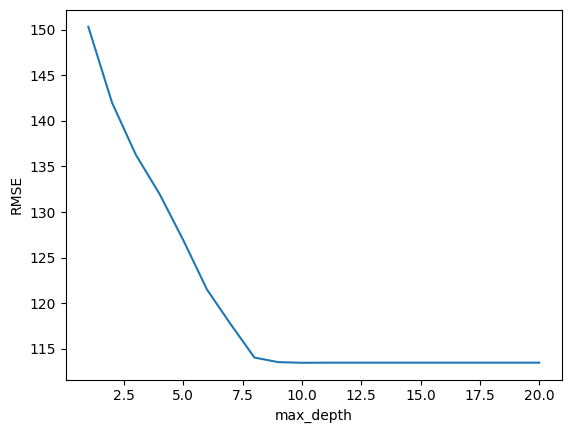

In [21]:
# Gráfica max_depth versus RMSE
plt.plot(max_depth_range, rmse_scores)
plt.xlabel('max_depth')
plt.ylabel('RMSE')

In [22]:
# Mejor RMSE (desempeño del modelo) y su correspondiente max_depth
sorted(zip(rmse_scores, max_depth_range))[::1][0]

(113.4370193349312, 10)

In [23]:
XTrain, XTest, yTrain, yTest = train_test_split(xtotal, ytotal, test_size=0.33, random_state=0)
m5 = DecisionTreeRegressor(max_depth=10, random_state=1,criterion="squared_error")
m5.fit(XTrain, yTrain)
y_pred = m5.predict(XTest)
rmse_m5=mean_squared_error(yTest, y_pred, squared=False)
rmse_m5

115.73032667446998

In [24]:
XTrain, XTest, yTrain, yTest = train_test_split(xtotal, ytotal, test_size=0.33, random_state=0)
m5variante = DecisionTreeRegressor(max_depth=5, random_state=1,criterion="squared_error")
m5variante.fit(XTrain, yTrain)
y_pred = m5variante.predict(XTest)
rmse_m5variante=mean_squared_error(yTest, y_pred, squared=False)
rmse_m5variante

127.15647239861144

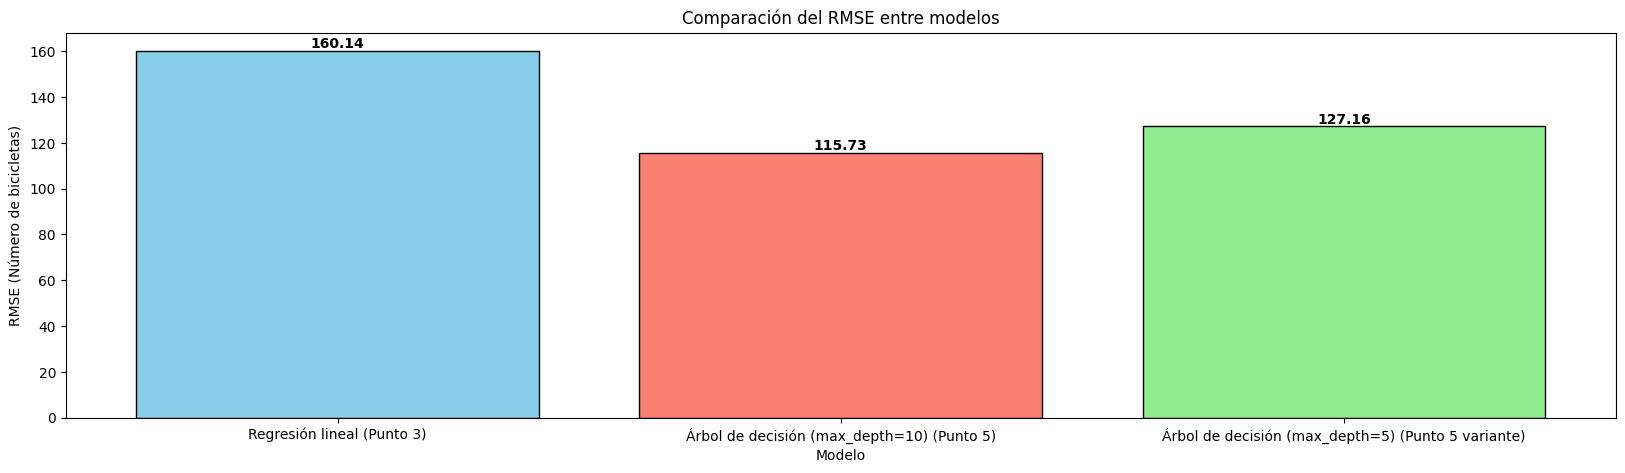

In [25]:
plt.figure(figsize=(20,5))
bars = plt.bar(
    ["Regresión lineal (Punto 3)", "Árbol de decisión (max_depth=10) (Punto 5)", "Árbol de decisión (max_depth=5) (Punto 5 variante)"],
    [rmse_m3, rmse_m5, rmse_m5variante],
    edgecolor="black",color=["skyblue", "salmon", "lightgreen"]
)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.2f}",
        ha="center",
        va="bottom",
        fontweight="bold"
    )


plt.title("Comparación del RMSE entre modelos")
plt.ylabel("RMSE (Número de bicicletas)")
plt.xlabel("Modelo")
plt.show()

#### Punto 5 - Analisis

Inicialmente, se calibró el modelo de árbol de decisión para regresión respecto al hiperparámetro de máxima profundidad (max_depth), con el fin de seleccionar el valor que permitiera mejorar el desempeño predictivo del modelo. Para ello, se evaluaron profundidades entre 1 y 21, utilizando validación cruzada de 10 folds, con el objetivo de identificar el valor que minimizara el RMSE. Se utilizó esta métrica debido a que es más interpretable que el MSE, ya que permite expresar el error en las mismas unidades de la variable respuesta, facilitando la comparación entre modelos.

A partir de este procedimiento de calibración, se seleccionó una profundidad de 10, la cual presentó el mejor desempeño promedio durante la validación cruzada.

Posteriormente, se construyó el modelo final utilizando una profundidad máxima de 10, una semilla igual a 1 para garantizar la reproducibilidad de los resultados, y el criterio criterion="squared_error", el cual utiliza la reducción del error cuadrático medio (MSE) para realizar cada división del árbol. Finalmente, el modelo obtuvo un RMSE de 115.73, lo que indica que, en promedio, el modelo comete un error de aproximadamente 115.73 bicicletas rentadas por predicción.

En la gráfica anterior se observa que el modelo de árbol de decisión captura mejor el patrón de relación entre las variables season y hour con respecto a la variable respuesta, en comparación con el modelo de regresión lineal. Esto puede explicarse porque la regresión lineal presenta limitaciones asociadas a la naturaleza de las variables predictoras, especialmente debido al comportamiento cíclico de la variable hour y al carácter categórico de la variable season, condiciones que son modeladas de manera más adecuada por los árboles de decisión.

En este sentido, el modelo de árbol de decisión logra una mejora aproximada del 27.73% en el RMSE frente al modelo de regresión lineal. Asimismo, se evidencia que el proceso de calibración del hiperparámetro max_depth contribuyó a mejorar el desempeño del modelo, ya que, por ejemplo, utilizando una profundidad máxima de 5, se obtiene un RMSE de 127.16, lo cual es superior al obtenido con profundidad 10. Esto demuestra que la calibración del hiperparámetro permitió optimizar el desempeño del modelo.

En conclusión, el modelo de árbol de decisión con profundidad máxima igual a 10 presenta un mejor desempeño que el modelo de regresión lineal, ya que logra capturar de manera más adecuada los patrones presentes en las variables utilizadas. Por lo tanto, el modelo seleccionado como mejor alternativa es el árbol de decisión calibrado con max_depth = 10.


## Parte B - Métodos de ensamblajes
En esta parte del taller se usará el conjunto de datos de Popularidad de Noticias Online. El objetivo es predecir si la notica es popular o no, la popularidad está dada por la cantidad de reacciones en redes sociales. Para más detalles puede visitar el siguiente enlace: [datos](https://archive.ics.uci.edu/ml/datasets/online+news+popularity).

### Datos popularidad de noticias

In [26]:
# Lectura de la información de archivo .csv
df = pd.read_csv('https://raw.githubusercontent.com/davidzarruk/MIAD_ML_NLP_2023/main/datasets/mashable.csv', index_col=0)
df.head()

,url,timedelta,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,...,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,Popular
0,http://mashable.com/2014/12/10/cia-torture-rep...,28.0,9.0,188.0,0.732620,1.0,0.844262,5.0,1.0,1.0,...,0.200000,0.80,-0.487500,-0.60,-0.250000,0.9,0.8,0.4,0.8,1
1,http://mashable.com/2013/10/18/bitlock-kicksta...,447.0,7.0,297.0,0.653199,1.0,0.815789,9.0,4.0,1.0,...,0.160000,0.50,-0.135340,-0.40,-0.050000,0.1,-0.1,0.4,0.1,0
2,http://mashable.com/2013/07/24/google-glass-po...,533.0,11.0,181.0,0.660377,1.0,0.775701,4.0,3.0,1.0,...,0.136364,1.00,0.000000,0.00,0.000000,0.3,1.0,0.2,1.0,0
3,http://mashable.com/2013/11/21/these-are-the-m...,413.0,12.0,781.0,0.497409,1.0,0.677350,10.0,3.0,1.0,...,0.100000,1.00,-0.195701,-0.40,-0.071429,0.0,0.0,0.5,0.0,0
4,http://mashable.com/2014/02/11/parking-ticket-...,331.0,8.0,177.0,0.685714,1.0,0.830357,3.0,2.0,1.0,...,0.100000,0.55,-0.175000,-0.25,-0.100000,0.0,0.0,0.5,0.0,0


In [27]:
# Definición variable de interes y variables predictoras
X = df.drop(['url', 'Popular'], axis=1)
y = df['Popular']
y.mean()

0.5

In [28]:
# División de la muestra en set de entrenamiento y prueba
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1)

### Punto 6 - Árbol de decisión y regresión logística
En la celda 6 construya un árbol de decisión y una regresión logística. Para el árbol calibre al menos un parámetro y evalúe el desempeño de cada modelo usando las métricas de Accuracy y F1-Score.

(0.6353333333333333, 2)

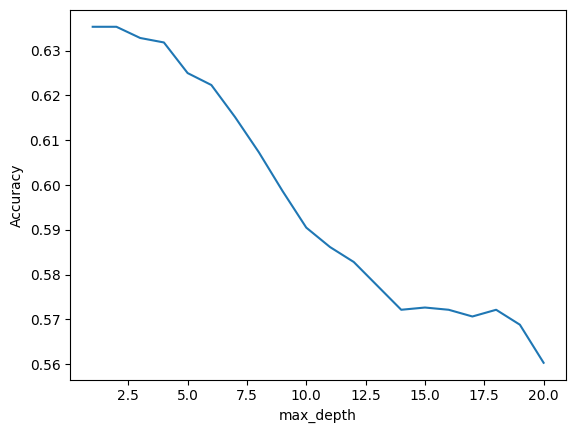

In [60]:
max_depth_range = range(1, 21)
accuracy_scores = []
for depth in max_depth_range:
    clf = DecisionTreeClassifier(max_depth=depth, random_state=1)
    accuracy_scores.append(cross_val_score(clf, X, y, cv=10, scoring='accuracy').mean())

plt.plot(max_depth_range, accuracy_scores)
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
sorted(zip(accuracy_scores, max_depth_range))[::-1][0]

(0.6322597160569876, 2)

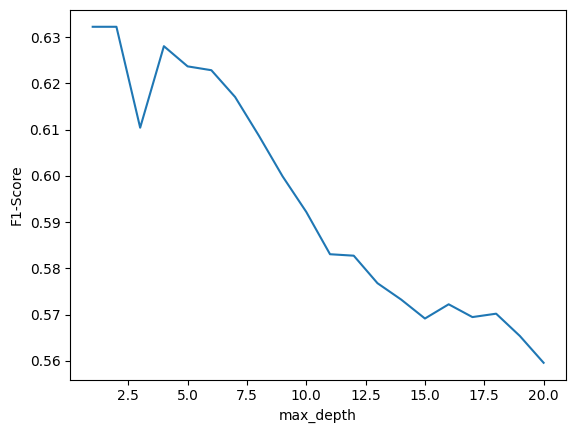

In [61]:
max_depth_range = range(1, 21)
accuracy_scores = []
for depth in max_depth_range:
    clf = DecisionTreeClassifier(max_depth=depth, random_state=1)
    accuracy_scores.append(cross_val_score(clf, X, y, cv=10, scoring='f1').mean())

plt.plot(max_depth_range, accuracy_scores)
plt.xlabel('max_depth')
plt.ylabel('F1-Score')
sorted(zip(accuracy_scores, max_depth_range))[::-1][0]

In [63]:
m6ad = DecisionTreeClassifier(max_depth=2, random_state=1)
m6ad.fit(X_train, y_train)
y_pred_m6ad = m6ad.predict(X_test)
accuracy_sm6ad= m6ad.score(X_test, y_test)
accuracy_m6ad= accuracy_score(y_test, y_pred_m6ad)
f1_m6ad = f1_score(y_test, y_pred_m6ad)

print("Accuracy árbol:", accuracy_m6ad)
print("F1-score árbol:", f1_m6ad)


Accuracy árbol: 0.6453333333333333
F1-score árbol: 0.6448598130841121


In [64]:
m6rl = LogisticRegression(max_iter=1000, random_state=1)
m6rl.fit(X_train, y_train)
y_pred_m6rl = m6rl.predict(X_test)
accuracy_m6rl = m6rl.score(X_test, y_test)
f1_m6rl = f1_score(y_test, y_pred_m6rl)
print("Accuracy regresión logística:", accuracy_m6rl)
print("F1-score regresión logística:", f1_m6rl)


Accuracy regresión logística: 0.616
F1-score regresión logística: 0.6049382716049383


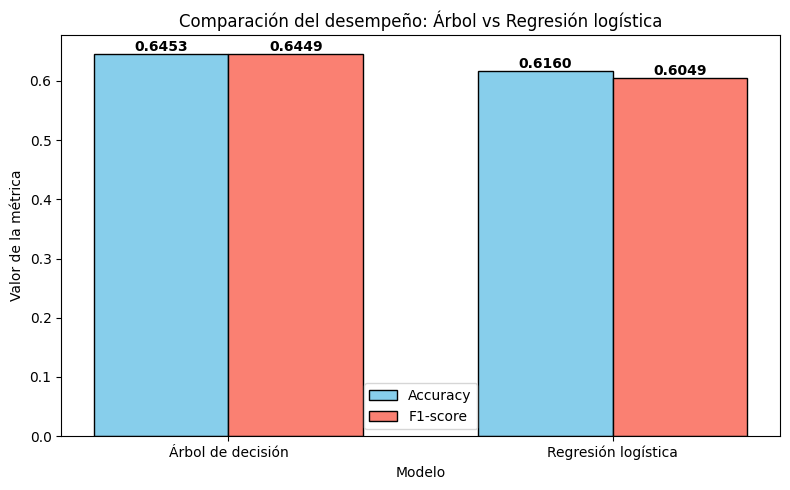

In [76]:
import numpy as np
import matplotlib.pyplot as plt

models = ["Árbol de decisión", "Regresión logística"]
accuracies = [accuracy_m6ad, accuracy_m6rl]
f1_scores = [f1_m6ad, f1_m6rl]

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(8,5))

bars1 = plt.bar(x - width/2, accuracies, width, label='Accuracy', color='skyblue', edgecolor='black')
bars2 = plt.bar(x + width/2, f1_scores, width, label='F1-score', color='salmon', edgecolor='black')

# Etiquetas encima de las barras
for bar in bars1:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height(),
             f"{bar.get_height():.4f}",
             ha='center',
             va='bottom',
             fontweight='bold')

for bar in bars2:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height(),
             f"{bar.get_height():.4f}",
             ha='center',
             va='bottom',
             fontweight='bold')

plt.xlabel('Modelo')
plt.xticks(x, models) 
plt.ylabel('Valor de la métrica')
plt.title('Comparación del desempeño: Árbol vs Regresión logística')
plt.legend()
plt.tight_layout()
plt.show()

#### Punto 6 - Analisis

Se construyeron dos modelos de clasificación y se evaluaron utilizando el conjunto de prueba:
* Se realizó un modelo de árbol de decisión; para este se hizo una calibración del parámetro de profundidad máxima, teniendo en cuenta accuracy y F1-score y aplicando validación cruzada para obtener la mejor profundidad. Al hacer la iteración de 1 hasta 20 por separado para cada métrica, se encontró que la profundidad que maximizaba la métrica correspondiente para ambas era 2, con un accuracy de 0.6353 y un F1-score de 0.6223. Debido a esto, se tomó esta profundidad de 2 para entrenar el modelo. Para este modelo se obtuvieron métricas de 0.6453 en accuracy y 0.6449 en F1-score.
* Se realizó un modelo de regresión logística; para este únicamente se utilizó un máximo de 1000 iteraciones y se evaluó en el conjunto de prueba. Para este se obtuvo un accuracy de 0.6160 y un F1-score de 0.6049.

En cuanto a ambos modelos, podemos decir que son bastante parecidos en cuanto a su rendimiento, ambos están en la misma magnitud. Sin embargo, el árbol obtiene un desempeño ligeramente superior. Por lo tanto, en este caso, aunque no necesariamente se debe escoger uno solo, se podría seleccionar este modelo si fuera necesario elegir únicamente uno. En cuanto a la magnitud del desempeño, es un modelo moderado que acierta alrededor del 60% de las predicciones, mejorando frente a la aleatoriedad. Asimismo, gracias al F1-score sabemos que el modelo tiene una precisión y un recall balanceados, lo cual lo convierte en una métrica adecuada en casos donde no se especifica qué tipo de error se quiere priorizar, por lo tanto, entre más alto sea su valor, mejor será el desempeño del modelo.

### Punto 7 - Votación Mayoritaria
En la celda 7 elabore un esamble con la metodología de **Votación mayoritaria** compuesto por 300 muestras bagged donde:

-las primeras 100 muestras de bootstrap vienen de árboles de decisión donde max_depth tome un valor de su elección\
-las segundas 100 muestras de bootstrap vienen de árboles de decisión donde min_samples_leaf tome un valor de su elección\
-las últimas 100 muestras de bootstrap vienen de regresiones logísticas

Evalúe cada uno de los tres modelos de manera independiente utilizando las métricas de Accuracy y F1-Score, luego evalúe el ensamble de modelos y compare los resultados. 

Nota: 

Para este ensamble de 300 modelos, deben hacer votación mayoritaria. Esto lo pueden hacer de distintas maneras. La más "fácil" es haciendo la votación "manualmente", como se hace a partir del minuto 5:45 del video de Ejemplo práctico de emsablajes en Coursera. Digo que es la más fácil porque si hacen la votación mayoritaria sobre las 300 predicciones van a obtener lo que se espera.

Otra opción es: para cada uno de los 3 tipos de modelos, entrenar un ensamble de 100 modelos cada uno. Predecir para cada uno de esos tres ensambles y luego predecir como un ensamble de los 3 ensambles. La cuestión es que la votación mayoritaria al usar los 3 ensambles no necesariamente va a generar el mismo resultado que si hacen la votación mayoritaria directamente sobre los 300 modelos. Entonces, para los que quieran hacer esto, deben hacer ese último cálculo con cuidado.

Para los que quieran hacerlo como ensamble de ensambles, digo que se debe hacer el ensamble final con cuidado por lo siguiente. Supongamos que:

* para los 100 árboles del primer tipo, la votación mayoritaria es: 55% de los modelos predicen que la clase de una observación es "1"
* para los 100 árboles del segundo tipo, la votación mayoritaria es: 55% de los modelos predicen que la clase de una observación es "1"
* para las 100 regresiones logísticas, la votación mayoritaria es: 10% de los modelos predicen que la clase de una observación es "1"

Si se hace la votación mayoritaria de los 300 modelos, la predicción de esa observación debería ser: (100*55%+100*55%+100*10%)/300 = 40% de los modelos votan porque la predicción debería ser "1". Es decir, la predicción del ensamble es "0" (dado que menos del 50% de modelos predijo un 1).

Sin embargo, si miramos cada ensamble por separado, el primer ensamble predice "1", el segundo ensamble predice "1" y el último ensamble predice "0". Si hago votación mayoritaria sobre esto, la predicción va a ser "1", lo cual es distinto a si se hace la votación mayoritaria sobre los 300 modelos.

In [30]:
# Celda 7


### Punto 8 - Votación Ponderada
En la celda 8 elabore un ensamble con la metodología de **Votación ponderada** compuesto por 300 muestras bagged para los mismos tres escenarios del punto 7. Evalúe los modelos utilizando las métricas de Accuracy y F1-Score

In [31]:
# Celda 8


### Punto 9 - Comparación y análisis de resultados
En la celda 9 comente sobre los resultados obtenidos con las metodologías usadas en los puntos 7 y 8, compare los resultados y enuncie posibles ventajas o desventajas de cada una de ellas.

In [32]:
# Celda 9